In [13]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import HumanMessage, AIMessage
import os

In [8]:
# importing the API key from .env file
load_dotenv()
MISTRAL_API_KEY = os.getenv("MISTRAL_API_KEY")

if not MISTRAL_API_KEY:
    raise ValueError("MISTRAL_API_KEY not found in environment variables")

In [9]:
# Initialize the model
llm = ChatMistralAI(
    model="mistral-small-latest",  # or "mistral-medium-latest", "mistral-large-latest"
    temperature=0.7,
    max_tokens=1024,
    api_key=os.environ["MISTRAL_API_KEY"]  # If not set in environment
)

# Test the connection
response = llm.invoke([HumanMessage(content="Hello, how are you?")])
print(response.content)

Hello! 😊 I'm just a virtual assistant, so I don't have feelings, but I'm here and ready to help you with anything you need! How about you—how are you doing today? Anything on your mind or something I can assist with?


In [10]:
class BlogGeneratorState(TypedDict):
    topic: str
    outline: str
    blog_post: str

In [ ]:
def generate_outline(state: BlogGeneratorState) -> BlogGeneratorState:
    topic = state['topic']
    prompt = f'Generate a detailed outline for a blog post on the topic: "{topic}".'

    response = llm.invoke([HumanMessage(content=prompt)])
    return {"outline": response.content}

def generate_blog_post(state: BlogGeneratorState) -> BlogGeneratorState:
    topic = state['topic']
    outline = state['outline']

    prompt = f'Write a blog post on the topic "{topic}" based on the following outline:\n{outline}'

    response = llm.invoke([HumanMessage(content=prompt)])

    return {"blog_post": response.content}

In [14]:
graph = StateGraph(BlogGeneratorState)

# add nodes to the graph
graph.add_node("generate_outline",generate_outline)
graph.add_node("generate_blog_post",generate_blog_post)

# add edges to the graph
graph.add_edge(START,'generate_outline')
graph.add_edge('generate_outline','generate_blog_post')
graph.add_edge('generate_blog_post',END)

workflow = graph.compile()

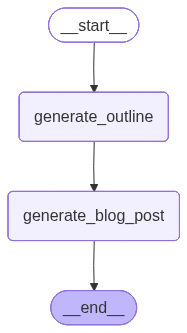

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [17]:
initial_state = {"topic": "The impact of AI on modern education"}
final_state = workflow.invoke(initial_state)

print("Generated Blog Post:\n")
print(final_state['blog_post'])

Generated Blog Post:

# **Revolutionizing Learning: How AI is Transforming Modern Education**

## **Introduction: The AI Education Revolution**

Imagine a classroom where every student receives a **personalized learning path**, where administrative tasks are automated, and where barriers to education—like language or disability—are effortlessly overcome. This isn’t a futuristic dream—it’s the **reality of AI in education today**.

By **2025**, the AI education market is projected to grow by **36%**, transforming how students learn and teachers instruct. From **adaptive learning platforms** to **AI-powered tutors**, technology is no longer an optional tool but a **necessity** in modern education. However, with this transformation comes **challenges**—ethical dilemmas, privacy concerns, and the risk of **over-automation** threatening the human touch in teaching.

In this post, we’ll explore:
✅ **How AI is reshaping education** through personalization, accessibility, and automation.
✅ **T